# CartPole-v1: Q-Learning vs DQN

| Część | Algorytm | Cel |
|---|---|---|
| **1** | Q-Learning z dyskretyzacją | punkt odniesienia, wpływ γ |
| **2** | DQN – przeszukiwanie hiperparametrów | optymalizacja obu architektur |
| **3** | Porównanie końcowe | wnioski |

Pliki pomocnicze:
- `cartpole_agent.py` – Q-learning z dyskretyzacją
- `dqn_model.py` – architektury `DQN_128x128` i `DQN_128x64`
- `dqn_train.py` – funkcja treningowa (tutorial PyTorch) + metryka optymalizacji
- `cartpole_visualize.py` – wizualizacja pygame (uruchom osobno po treningu)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch

from cartpole_agent import CartPoleQLearningAgent
from dqn_model import DQN_128x128, DQN_128x64
from dqn_train import train_dqn, discounted_total

device = torch.device(
    'cuda' if torch.cuda.is_available() else
    'mps'  if torch.backends.mps.is_available() else
    'cpu'
)
print(f'Urządzenie: {device}')


def plot_results(results_dict, title, window=50, max_score=500, ylabel='Suma nagród'):
    plt.figure(figsize=(12, 5))
    for label, data in results_dict.items():
        avg = np.convolve(data, np.ones(window) / window, mode='valid')
        plt.plot(range(window - 1, len(data)), avg, label=label, linewidth=2)
    plt.axhline(y=max_score, color='red', linestyle='--', alpha=0.4, label=f'Max ({max_score})')
    plt.title(title)
    plt.xlabel('Epizod')
    plt.ylabel(f'{ylabel} (okno={window})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Urządzenie: cuda


---
## Część 1 – Q-Learning z dyskretyzacją

Każda z 4 zmiennych obserwacji jest mapowana na kubełki (`np.digitize`).
Sufit wynikowy (~100–150 pkt) wynika z utraty informacji przy dyskretyzacji.

### Eksperyment: wpływ γ ∈ {0.5, 0.9, 0.99}

Trenuję Q-learning...
  γ = 0.5 ... gotowe
  γ = 0.9 ... gotowe
  γ = 0.99 ... gotowe


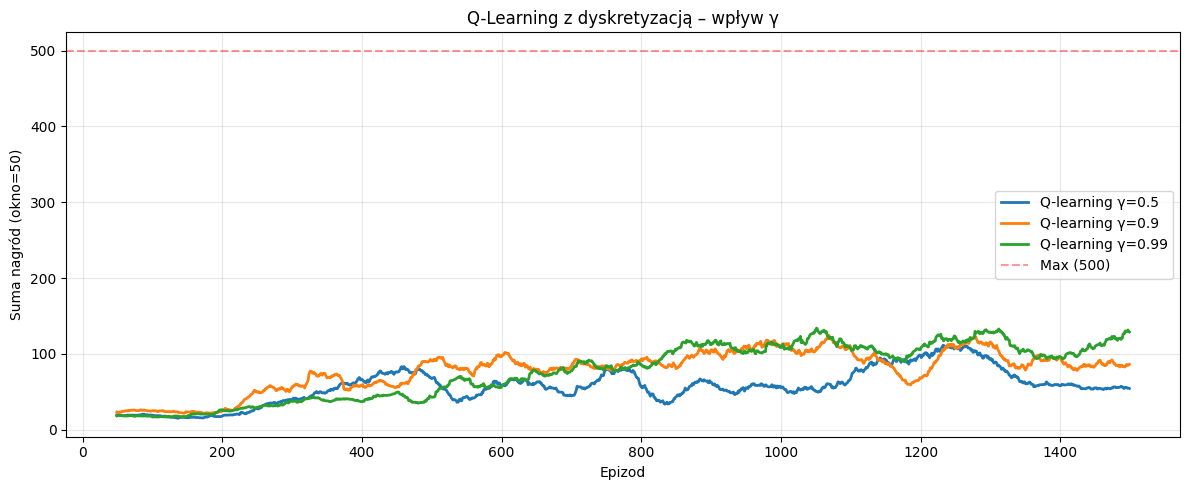


Zdyskontowana nagroda (γ=0.9, pierwsze 1000 ep.):
  Q-learning γ=0.5: 209
  Q-learning γ=0.9: 229
  Q-learning γ=0.99: 182


In [2]:
def train_qlearning(gamma, n_episodes=1500):
    env   = gym.make('CartPole-v1')
    agent = CartPoleQLearningAgent(
        n_actions=env.action_space.n,
        learning_rate=0.1, discount_factor=gamma,
        epsilon=1.0, epsilon_decay=0.995, min_epsilon=0.01
    )
    rewards = []
    for _ in range(n_episodes):
        state, _ = env.reset()
        total, done = 0, False
        while not done:
            action = agent.get_action(state)
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.update(state, action, reward, next_state, terminated)
            state = next_state
            total += reward
        agent.decay_epsilon()
        rewards.append(total)
    env.close()
    return rewards


print('Trenuję Q-learning...')
ql_results = {}
for g in [0.5, 0.9, 0.99]:
    print(f'  γ = {g}', end=' ... ', flush=True)
    ql_results[f'Q-learning γ={g}'] = train_qlearning(g)
    print('gotowe')

plot_results(ql_results, 'Q-Learning z dyskretyzacją – wpływ γ')

print('\nZdyskontowana nagroda (γ=0.9, pierwsze 1000 ep.):')
for label, rewards in ql_results.items():
    print(f'  {label}: {discounted_total(rewards, gamma=0.9, max_episodes=1000):.0f}')

---
## Część 2 – DQN: przeszukiwanie hiperparametrów

Testujemy 2 architektury × 3 konfiguracje = 6 kombinacji.

**Metryka:** całkowita nagroda z 600 epizodów przy γ=0.99.

| Konfiguracja | Zmiana względem bazowej |
|---|---|
| bazowa | - |
| wolniejszy decay | EPS_DECAY=1000 (dłuższa eksploracja) |
| niższe LR | LR=1e-4 (ostrożniejsze aktualizacje wag) |

In [3]:
hp_grid = [
    {'name': 'bazowa',           'BATCH_SIZE': 256, 'LR': 5e-4, 'EPS_DECAY': 500 },
    {'name': 'wolniejszy decay', 'BATCH_SIZE': 256, 'LR': 5e-4, 'EPS_DECAY': 1000},
    {'name': 'niższe LR',        'BATCH_SIZE': 256, 'LR': 1e-4, 'EPS_DECAY': 500 },
]

dqn_results    = {}
dqn_scores     = {}
trained_models = {}
GAMMA_DQN = 0.99
N_EP      = 600

for arch_name, arch_class in [('128x128', DQN_128x128), ('128x64', DQN_128x64)]:
    print(f'\n=== Architektura: {arch_name} ===')
    for cfg in hp_grid:
        label = f'DQN {arch_name} [{cfg["name"]}]'
        print(f'  {label}', end=' ... ', flush=True)
        net, durations = train_dqn(
            model_class=arch_class, n_episodes=N_EP,
            BATCH_SIZE=cfg['BATCH_SIZE'], GAMMA=GAMMA_DQN,
            EPS_START=0.9, EPS_END=0.05, EPS_DECAY=cfg['EPS_DECAY'],
            TAU=0.01, LR=cfg['LR'], device=device
        )
        score = discounted_total(durations, gamma=GAMMA_DQN, max_episodes=N_EP)
        dqn_results[label]    = durations
        dqn_scores[label]     = score
        trained_models[label] = net
        print(f'nagroda = {score:.0f}')

print('\nRanking')
for label, score in sorted(dqn_scores.items(), key=lambda x: -x[1]):
    print(f'  {score:10.0f}  {label}')


=== Architektura: 128x128 ===
  DQN 128x128 [bazowa] ... nagroda = 17902
  DQN 128x128 [wolniejszy decay] ... nagroda = 16317
  DQN 128x128 [niższe LR] ... nagroda = 2046

=== Architektura: 128x64 ===
  DQN 128x64 [bazowa] ... nagroda = 16747
  DQN 128x64 [wolniejszy decay] ... nagroda = 10725
  DQN 128x64 [niższe LR] ... nagroda = 1221

Ranking
       17902  DQN 128x128 [bazowa]
       16747  DQN 128x64 [bazowa]
       16317  DQN 128x128 [wolniejszy decay]
       10725  DQN 128x64 [wolniejszy decay]
        2046  DQN 128x128 [niższe LR]
        1221  DQN 128x64 [niższe LR]


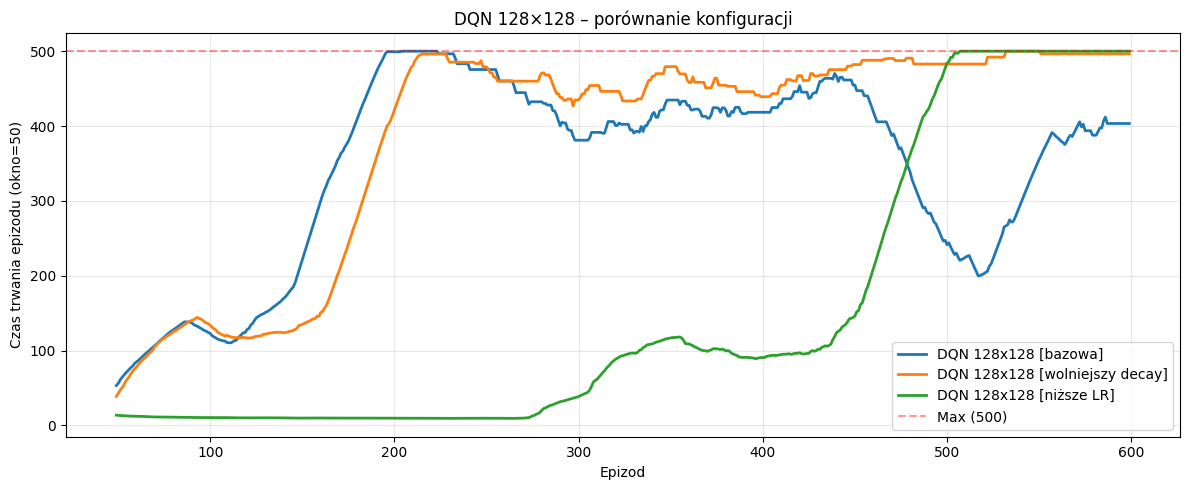

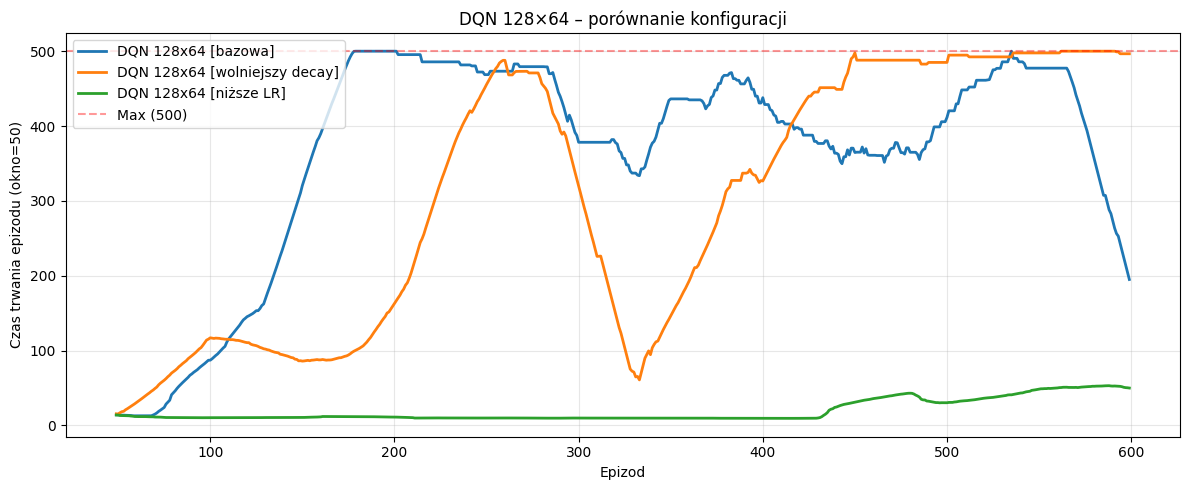

In [4]:
plot_results(
    {k: v for k, v in dqn_results.items() if '128x128' in k},
    title='DQN 128×128 – porównanie konfiguracji', ylabel='Czas trwania epizodu'
)
plot_results(
    {k: v for k, v in dqn_results.items() if '128x64' in k},
    title='DQN 128×64 – porównanie konfiguracji', ylabel='Czas trwania epizodu'
)

---
## Część 3 – Porównanie końcowe

Najlepsza konfiguracja DQN: DQN 128x128 [bazowa]  (zdysk. nagroda: 17902)


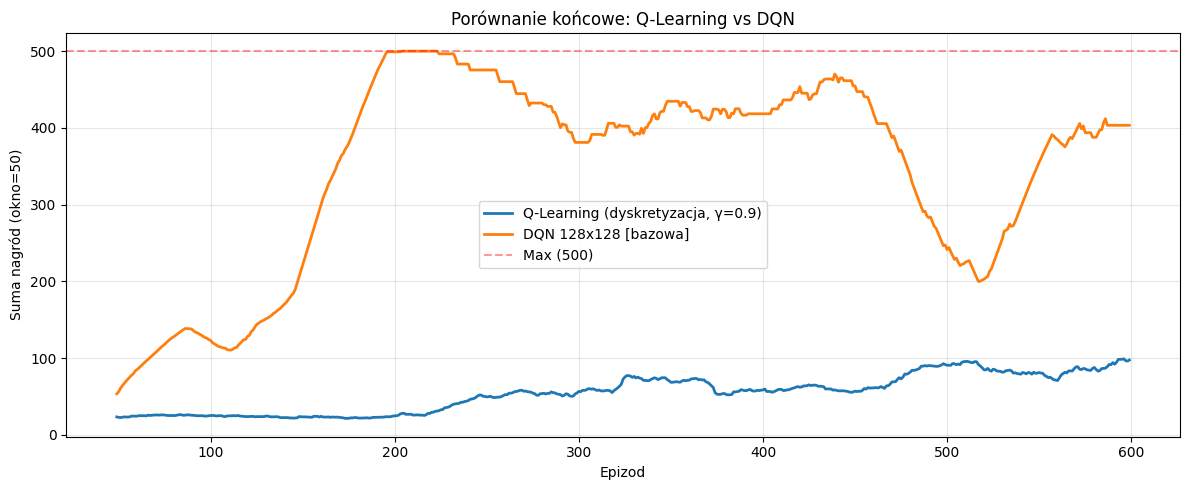

In [5]:
best_label = max(dqn_scores, key=dqn_scores.get)
print(f'Najlepsza konfiguracja DQN: {best_label}  (zdysk. nagroda: {dqn_scores[best_label]:.0f})')

n = min(len(ql_results['Q-learning γ=0.9']), len(dqn_results[best_label]))
plot_results(
    {
        'Q-Learning (dyskretyzacja, γ=0.9)': ql_results['Q-learning γ=0.9'][:n],
        best_label:                           dqn_results[best_label][:n],
    },
    title='Porównanie końcowe: Q-Learning vs DQN'
)

In [7]:
# Zapisz najlepszy model do pliku — używany przez cartpole_visualize.py
torch.save(trained_models[best_label].state_dict(), 'best_policy_net.pt')
print(f'Model zapisany: best_policy_net.pt')
print(f'Architektura:   {best_label}')

Model zapisany: best_policy_net.pt
Architektura:   DQN 128x128 [bazowa]
